<a href="https://colab.research.google.com/github/blade-runerr/ML-practise/blob/main/TEST_Dropout_BatchNorm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="mnist",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="mnist",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.66MB/s]


In [ ]:
from torch import nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=28*28, out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10, out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10, out_features=10),
)
model


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
  (2): ReLU()
  (3): Linear(in_features=10, out_features=10, bias=True)
  (4): ReLU()
  (5): Linear(in_features=10, out_features=10, bias=True)
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch

def evaluate(model, dataloader):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X, y in dataloader:
            logits = model(X)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, average='macro')
    recall = recall_score(all_targets, all_preds, average='macro')
    f1 = f1_score(all_targets, all_preds, average='macro')

    return acc, precision, recall, f1

In [ ]:
loss_fn = nn.CrossEntropyLoss()

In [ ]:
def run(model, dataloader, loss_function, optimizer=None):
    # set the model to evaluation or training mode
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0

    if optimizer is None:
        # 🔥 TEST MODE (без градиентов)
        with torch.no_grad():
            for X, y in dataloader:
                pred = model(X)
                loss = loss_function(pred, y)

                total_loss += loss.item()
    else:
        # 🔥 TRAIN MODE (с градиентами)
        for X, y in dataloader:
            pred = model(X)
            loss = loss_function(pred, y)

            total_loss += loss.item()

            # compute gradients
            loss.backward()

            # update weights
            optimizer.step()

            # reset gradients
            optimizer.zero_grad()

    return total_loss / len(dataloader)

In [ ]:
from IPython.display import clear_output

def show_losses(train_loss_hist, test_loss_hist):
    clear_output()

    plt.figure(figsize=(12,4))

    plt.subplot(1, 2, 1)
    plt.title('Train Loss')
    plt.plot(np.arange(len(train_loss_hist)), train_loss_hist)
    plt.yscale('log')
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.title('Test Loss')
    plt.plot(np.arange(len(test_loss_hist)), test_loss_hist)
    plt.yscale('log')
    plt.grid()

    plt.show()

In [ ]:
from torch import optim

# your code here
optimizer = optim.SGD(model.parameters(), lr=0.001)

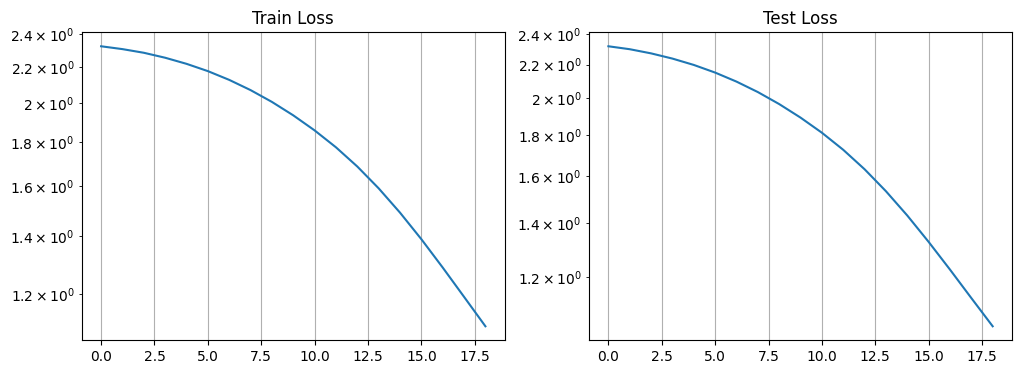

Epoch 19: acc=0.7429, f1=0.7342


In [ ]:
BATCH_SIZE = 100
NUM_EPOCHS = 20

# your code here
metrics_hist = []
# your code here
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE,shuffle=False)

train_loss_hist = []
test_loss_hist = []

for i in range(NUM_EPOCHS):
    train_loss = run(model, train_loader, loss_fn, optimizer)
    train_loss_hist.append(train_loss)

    test_loss = run(model, test_loader, loss_fn)
    test_loss_hist.append(test_loss)

    acc, precision, recall, f1 = evaluate(model, test_loader)
    metrics_hist.append((acc, precision, recall, f1))

    print(f"Epoch {i}: acc={acc:.4f}, f1={f1:.4f}")

    if i % 2 == 0:
        show_losses(train_loss_hist, test_loss_hist)

In [ ]:
best_f1 = max(m[3] for m in metrics_hist)
best_acc = max(m[0] for m in metrics_hist)
min_test_loss = min(test_loss_hist)
print(f"Best F1: {best_f1:.4f}")
print(f"Best Accuracy: {best_acc:.4f}")
print(f"Min Test Loss: {min_test_loss:.4f}")

Best F1: 0.7342
Best Accuracy: 0.7429
Min Test Loss: 0.9649


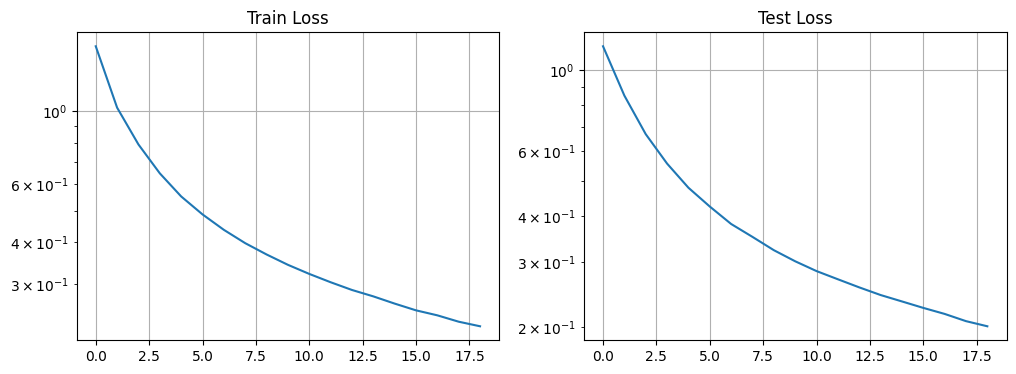

Epoch 19: acc=0.9507, f1=0.9503


In [ ]:

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=28*28, out_features=128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(in_features=64, out_features=10),
)
optimizer = optim.SGD(model.parameters(), lr=0.001)
BATCH_SIZE = 100
NUM_EPOCHS = 20
metrics_hist = []
# your code here
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE,shuffle=False)

train_loss_hist = []
test_loss_hist = []

for i in range(NUM_EPOCHS):
    train_loss = run(model, train_loader, loss_fn, optimizer)
    train_loss_hist.append(train_loss)

    test_loss = run(model, test_loader, loss_fn)
    test_loss_hist.append(test_loss)

    acc, precision, recall, f1 = evaluate(model, test_loader)
    metrics_hist.append((acc, precision, recall, f1))

    print(f"Epoch {i}: acc={acc:.4f}, f1={f1:.4f}")

    if i % 2 == 0:
        show_losses(train_loss_hist, test_loss_hist)

In [ ]:
best_f1 = max(m[3] for m in metrics_hist)
best_acc = max(m[0] for m in metrics_hist)
min_test_loss = min(test_loss_hist)
print(f"Best F1: {best_f1:.4f}")
print(f"Best Accuracy: {best_acc:.4f}")
print(f"Min Test Loss: {min_test_loss:.4f}")

Best F1: 0.9503
Best Accuracy: 0.9507
Min Test Loss: 0.1966


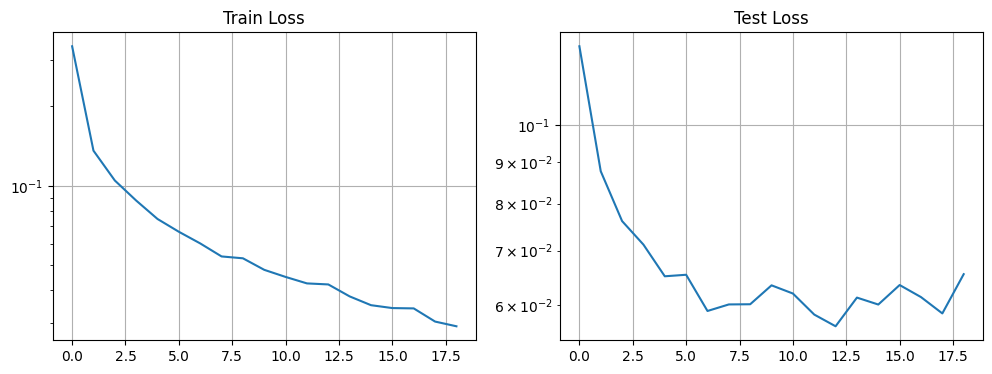

Epoch 19: acc=0.9824, f1=0.9823


In [ ]:

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=28*28, out_features=128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(in_features=128, out_features=64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(in_features=64, out_features=10),
)
optimizer = optim.Adam(model.parameters(), lr=0.001)
BATCH_SIZE = 100
NUM_EPOCHS = 20
metrics_hist = []
# your code here
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE,shuffle=False)

train_loss_hist = []
test_loss_hist = []

for i in range(NUM_EPOCHS):
    train_loss = run(model, train_loader, loss_fn, optimizer)
    train_loss_hist.append(train_loss)

    test_loss = run(model, test_loader, loss_fn)
    test_loss_hist.append(test_loss)

    acc, precision, recall, f1 = evaluate(model, test_loader)
    metrics_hist.append((acc, precision, recall, f1))

    print(f"Epoch {i}: acc={acc:.4f}, f1={f1:.4f}")

    if i % 2 == 0:
        show_losses(train_loss_hist, test_loss_hist)

In [ ]:
best_f1 = max(m[3] for m in metrics_hist)
best_acc = max(m[0] for m in metrics_hist)
min_test_loss = min(test_loss_hist)
print(f"Best F1: {best_f1:.4f}")
print(f"Best Accuracy: {best_acc:.4f}")
print(f"Min Test Loss: {min_test_loss:.4f}")

Best F1: 0.9835
Best Accuracy: 0.9835
Min Test Loss: 0.0565


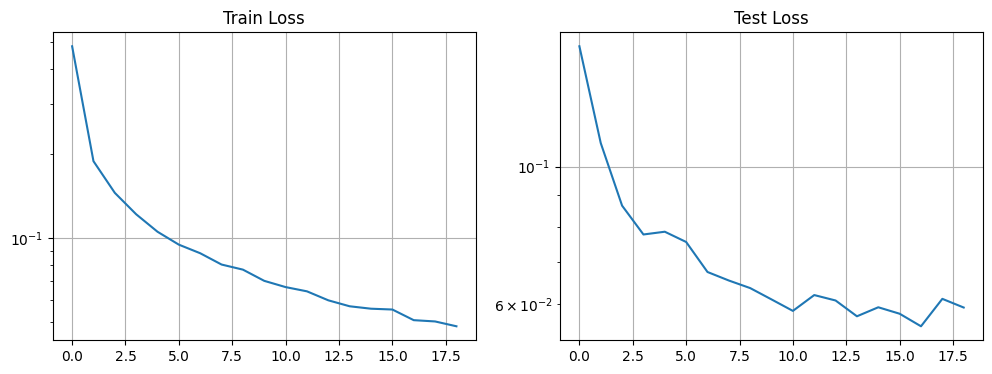

Epoch 19: acc=0.9832, f1=0.9830


In [ ]:

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=28*28, out_features=128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(in_features=128, out_features=64),
    nn.BatchNorm1d(64),
    nn.GELU(),
    nn.Dropout(p=0.2),
    nn.Linear(in_features=64, out_features=10),
)
optimizer = optim.Adam(model.parameters(), lr=0.0005,weight_decay=1e-4)
BATCH_SIZE = 100
NUM_EPOCHS = 20
metrics_hist = []
# your code here
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE,shuffle=False)

train_loss_hist = []
test_loss_hist = []

for i in range(NUM_EPOCHS):
    train_loss = run(model, train_loader, loss_fn, optimizer)
    train_loss_hist.append(train_loss)

    test_loss = run(model, test_loader, loss_fn)
    test_loss_hist.append(test_loss)

    acc, precision, recall, f1 = evaluate(model, test_loader)
    metrics_hist.append((acc, precision, recall, f1))

    print(f"Epoch {i}: acc={acc:.4f}, f1={f1:.4f}")

    if i % 2 == 0:
        show_losses(train_loss_hist, test_loss_hist)

In [ ]:
best_f1 = max(m[3] for m in metrics_hist)
best_acc = max(m[0] for m in metrics_hist)
min_test_loss = min(test_loss_hist)
print(f"Best F1: {best_f1:.4f}")
print(f"Best Accuracy: {best_acc:.4f}")
print(f"Min Test Loss: {min_test_loss:.4f}")

Best F1: 0.9831
Best Accuracy: 0.9832
Min Test Loss: 0.0552


В ходе экспериментов было установлено, что наибольшее влияние на качество модели оказали Batch Normalization и Dropout. BatchNorm значительно улучшает сходимость и стабильность обучения, а Dropout позволяет снизить переобучение и повысить обобщающую способность модели. Использование более сложной функции активации (GELU) не привело к значительному улучшению качества, что можно объяснить относительной простотой задачи классификации MNIST. Оптимальной оказалась архитектура, сочетающая BatchNorm, Dropout и ReLU, показавшая наилучшие значения метрик на тестовой выборке.